In [1]:
import pybaseball as pb
from pybaseball import playerid_lookup
import pandas as pd
import numpy as np

In [2]:
data = pd.read_parquet('data/statcast_data_2025.parquet')
data.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches,swing,whiff,in_zone,out_zone,chase
0,SI,2025-03-31,96.6,0.22,7.01,"Bautista, Félix",608324,642585,field_out,hit_into_play,...,<NA>,<NA>,<NA>,<NA>,<NA>,True,False,True,False,False
1,SL,2025-03-31,86.8,-0.5,6.78,"Bautista, Félix",608324,642585,None,ball,...,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,True,False
2,SI,2025-03-31,97.8,0.18,7.03,"Bautista, Félix",646240,642585,walk,ball,...,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,True,False
3,SI,2025-03-31,97.8,0.18,6.95,"Bautista, Félix",646240,642585,None,foul,...,2.326145,17.900737,28.548852,43.512056,18.085586,True,False,True,False,False
4,SI,2025-03-31,97.7,0.05,7.02,"Bautista, Félix",646240,642585,None,called_strike,...,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,True,False


In [131]:
def get_pitcher_statcast_data(total_statcast_data: pd.DataFrame, player_name: str, opponent_team: str = None, batter_name: str = None, handedness = None) -> pd.DataFrame:
    """
    Filters a pre-loaded Statcast DataFrame for a specific pitcher, and optionally 
    by opponent or specific batter.

    Args:
        total_statcast_data (pd.DataFrame): The full, preprocessed Statcast dataset.
        player_name (str): The name of the pitcher (e.g., 'Gerrit Cole').
        opponent_team (str, optional): Team code of the opponent (e.g., 'BOS').
        batter_name (str, optional): The name of the batter (e.g., 'Mike Trout').

    Returns:
        pd.DataFrame: A DataFrame of the filtered Statcast data.
    """
    
    if total_statcast_data is None or total_statcast_data.empty:
        print("Error: Input dataframe is empty or None.")
        return pd.DataFrame()

    print(f"--- Processing data for {player_name} ---")

    # Create a copy to avoid SettingWithCopy warnings on the original dataset
    filtered_data = total_statcast_data.copy()

    # 1. Filter by Pitcher ID
    try:
        # Note: This lookup requires an internet connection or cached pybaseball data
        lookup = playerid_lookup(player_name.split()[-1], player_name.split()[0])
        pitcher_id = lookup['key_mlbam'].iloc[0]
        
        filtered_data = filtered_data[filtered_data['pitcher'] == pitcher_id].copy()
        print(f"Filtered by Pitcher ({player_name}, ID: {pitcher_id}): {len(filtered_data)} pitches remaining.")
    except (IndexError, AttributeError):
        print(f"Error: Could not find MLBAM ID for pitcher: {player_name}. No data filtered for pitcher.")
        return pd.DataFrame()

    # 2. Filter by Opponent Team
    if opponent_team:
        # Infer the pitcher's team based on who is fielding
        filtered_data.loc[:, 'inferred_pitcher_team'] = np.where(
            filtered_data['inning_topbot'] == 'top',
            filtered_data['home_team'],
            filtered_data['away_team']
        )
        
        # Get the pitcher's primary team ID from this subset
        try:
            pitcher_team_id = filtered_data['inferred_pitcher_team'].mode().iloc[0]
        except IndexError:
            pitcher_team_id = None
        
        if pitcher_team_id:
            opponent_team_upper = opponent_team.upper()
            filtered_data = filtered_data[
                # Pitcher is AWAY, Opponent is HOME
                ((filtered_data['home_team'] == opponent_team_upper) & (filtered_data['away_team'] == pitcher_team_id)) |
                # Pitcher is HOME, Opponent is AWAY
                ((filtered_data['away_team'] == opponent_team_upper) & (filtered_data['home_team'] == pitcher_team_id))
            ].copy()
            print(f"Filtered by Opponent ({opponent_team_upper}): {len(filtered_data)} pitches remaining.")
        else:
            print("Warning: Could not determine pitcher's team to apply opponent filter.")
        
        # Clean up temp column
        filtered_data = filtered_data.drop(columns=['inferred_pitcher_team'], errors='ignore')

    # 3. Filter by Batter Name
    if batter_name:
        try:
            batter_lookup = playerid_lookup(batter_name.split()[-1], batter_name.split()[0])
            batter_id = batter_lookup['key_mlbam'].iloc[0]
            
            filtered_data = filtered_data[filtered_data['batter'] == batter_id].copy()
            print(f"Filtered by Batter ({batter_name}, ID: {batter_id}): {len(filtered_data)} pitches remaining.")
        except (IndexError, AttributeError):
            print(f"Warning: Could not find MLBAM ID for batter: {batter_name}. Batter filter skipped.")


    if handedness:
        filtered_data = filtered_data[filtered_data['stand'] == handedness].copy()
        print(f"Filtered by Handedness ({handedness}): {len(filtered_data)} pitches remaining.")
            
    if filtered_data.empty:
        print("No data remaining after applying all filters.")

    return filtered_data.reset_index(drop=True)

data2 = get_pitcher_statcast_data(data, 'Bryan King', handedness='L')
data2.head()

--- Processing data for Bryan King ---


Filtered by Pitcher (Bryan King, ID: 687911): 1028 pitches remaining.
Filtered by Handedness (L): 293 pitches remaining.


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches,swing,whiff,in_zone,out_zone,chase
0,ST,2025-04-30,78.9,2.78,5.47,"King, Bryan",700242,687911,field_out,hit_into_play,...,8.357586,1.670101,20.003576,33.636653,32.942147,True,False,True,False,False
1,FF,2025-04-30,91.3,2.79,5.53,"King, Bryan",682985,687911,single,hit_into_play,...,-23.644851,28.84779,45.10079,25.008659,16.878303,True,False,False,True,True
2,FF,2025-04-30,92.2,2.82,5.51,"King, Bryan",682985,687911,None,called_strike,...,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,True,False,False
3,ST,2025-04-30,80.4,3.03,5.35,"King, Bryan",682985,687911,None,ball,...,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,True,False
4,ST,2025-04-30,80.3,2.74,5.47,"King, Bryan",682985,687911,None,ball,...,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,True,False


In [66]:
data2.groupby('pitch_name')['estimated_woba_using_speedangle'].mean().sort_values(ascending=False).reset_index()

,pitch_name,estimated_woba_using_speedangle
0,Sinker,0.357698
1,4-Seam Fastball,0.291043
2,Changeup,0.265611
3,Knuckle Curve,0.2464
4,Cutter,0.1526
5,Slider,0.12


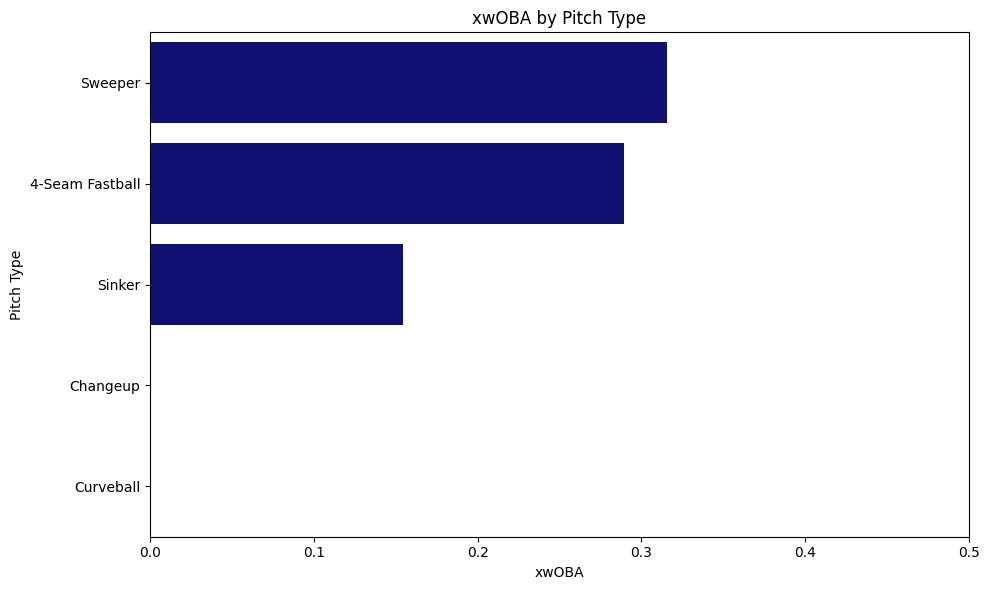

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute table
df_plot = (
    data2.groupby('pitch_name')['estimated_woba_using_speedangle']
         .mean()
         .sort_values(ascending=False)
         .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=df_plot,
    x='estimated_woba_using_speedangle',
    y='pitch_name',
    color = 'navy'
)

plt.xlim(0, 0.5)
plt.xlabel("xwOBA")
plt.ylabel("Pitch Type")
plt.title("xwOBA by Pitch Type")
plt.tight_layout()
plt.show()


In [85]:
import pandas as pd
import numpy as np

def aggregate_hitting_stats(df: pd.DataFrame):
    """
    Computes aggregate offensive metrics (AVG, OBP, SLG, wOBA, xwOBA, etc.)
    from Statcast pitch-level data.
    """

    d = df.copy()
    d['pitch_type']

    # -------------------------
    # Basic event flags
    # -------------------------
    d["is_ab"] = d["events"].isin([
        "single","double","triple","home_run","field_out","force_out",
        "grounded_into_double_play","strikeout","strikeout_double_play",
        "field_error","fielders_choice","fielders_choice_out"
    ])

    d["is_hit"] = d["events"].isin(["single","double","triple","home_run"])

    d["single"] = d["events"].eq("single")
    d["double"] = d["events"].eq("double")
    d["triple"] = d["events"].eq("triple")
    d["hr"]     = d["events"].eq("home_run")

    d["bb"]  = d["events"].eq("walk")
    d["ibb"] = d["events"].eq("intent_walk")
    d["hbp"] = d["events"].eq("hit_by_pitch")
    d["sf"]  = d["events"].eq("sac_fly")

    # -------------------------
    # Plate appearances
    # -------------------------
    d["pa_event"] = d["events"].notna()
    PA = d["pa_event"].sum()
    AB = d["is_ab"].sum()

    # -------------------------
    # Traditional stats
    # -------------------------
    H  = d["is_hit"].sum()
    BB = d["bb"].sum()
    IBB = d["ibb"].sum()
    HBP = d["hbp"].sum()
    SF  = d["sf"].sum()

    singles = d["single"].sum()
    doubles = d["double"].sum()
    triples = d["triple"].sum()
    HR = d["hr"].sum()

    # -------------------------
    # TB / AVG / OBP / SLG
    # -------------------------
    TB = singles + 2*doubles + 3*triples + 4*HR

    AVG = H / AB if AB > 0 else np.nan
    OBP = (H + BB + HBP) / (AB + BB + HBP + SF) if (AB + BB + HBP + SF) > 0 else np.nan
    SLG = TB / AB if AB > 0 else np.nan

    # -------------------------
    # wOBA (use Statcast estimated wOBA when available)
    # -------------------------
    if "woba_value" in d.columns:
        # Statcast's actual wOBA value per plate appearance
        wOBA = d["woba_value"].sum() / d["pa_event"].sum()
    else:
        wOBA = np.nan

    # Expected wOBA (xwOBA)
    if "estimated_woba_using_speedangle" in d.columns:
        xwOBA = d["estimated_woba_using_speedangle"].mean()
    else:
        xwOBA = np.nan

    # -------------------------
    # Output table
    # -------------------------
    out = pd.DataFrame({
        "PA":  [PA],
        "AB":  [AB],
        "H":   [H],
        "1B":  [singles],
        "2B":  [doubles],
        "3B":  [triples],
        "HR":  [HR],
        "BB":  [BB],
        "IBB": [IBB],
        "HBP": [HBP],
        "SF":  [SF],
        "TB":  [TB],
        "AVG":  [AVG],
        "OBP":  [OBP],
        "SLG":  [SLG],
        "OPS":  [OBP + SLG if not np.isnan(OBP+SLG) else np.nan],
        "wOBA": [wOBA],
        "xwOBA": [xwOBA]
    })

    return out


# Example usage:
agg_table = aggregate_hitting_stats(data2)
agg_table


,PA,AB,H,1B,2B,3B,HR,BB,IBB,HBP,SF,TB,AVG,OBP,SLG,OPS,wOBA,xwOBA
0,708,639,129,91,19,3,16,53,1,7,2,202,0.201878,0.269615,0.316119,0.585734,0.265466,0.272652


In [17]:
hb_id = pb.playerid_lookup("King", "Bryan")['key_mlbam'][0]
hb_data = data[data.pitcher == hb_id]
hb_data.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches,swing,whiff,in_zone,out_zone,chase
10763,ST,2025-04-30,78.9,2.78,5.47,"King, Bryan",700242,687911,field_out,hit_into_play,...,8.357586,1.670101,20.003576,33.636653,32.942147,True,False,True,False,False
10764,ST,2025-04-30,79.7,2.68,5.45,"King, Bryan",679529,687911,field_out,hit_into_play,...,31.052635,-25.703151,55.053466,29.327971,48.070165,True,False,False,True,True
10765,FF,2025-04-30,93.4,2.69,5.55,"King, Bryan",679529,687911,None,foul,...,-14.876429,23.982206,33.872811,36.046875,7.834719,True,False,True,False,False
10766,ST,2025-04-30,81.2,2.88,5.43,"King, Bryan",679529,687911,None,foul,...,30.807269,-26.550095,50.693413,30.507151,47.642223,True,False,False,True,True
10767,FF,2025-04-30,93.3,2.75,5.52,"King, Bryan",679529,687911,None,called_strike,...,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,True,False,False


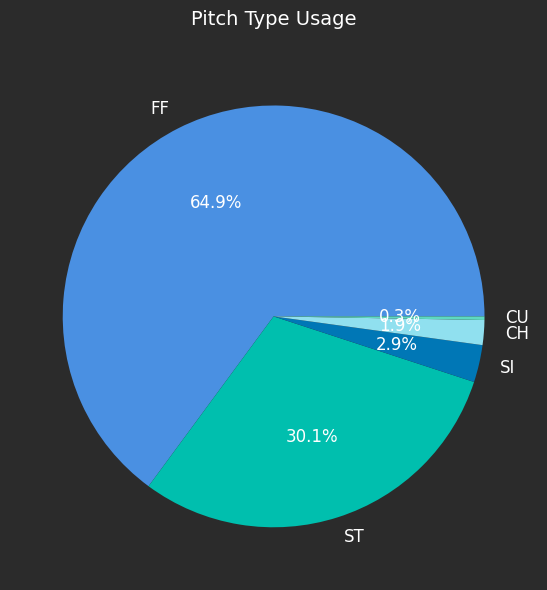

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_usage(player_data):
    # Usage data
    usage = player_data['pitch_type'].value_counts(normalize = True).reset_index(name = 'Usage')

    # Dark background setup
    fig, ax = plt.subplots(figsize = (6,6), facecolor = "#2b2b2b")
    ax.set_facecolor("#2b2b2b")

    # Cool-toned color palette for dark background
    colors = [
        "#4A90E2", "#00bfae", "#0077b6",
        "#90e0ef", "#5dd9c1", "#1e90ff"
    ]

    # Pie chart with white labels and clean contrast
    wedges, texts, autotexts = ax.pie(
        usage['Usage'],
        labels = usage['pitch_type'],
        autopct = '%1.1f%%',
        textprops = {'color': 'white', 'fontsize': 12},
        colors = colors
    )

    # Title styling
    ax.set_title("Pitch Type Usage", color = "white", fontsize = 14, pad = 20)

    plt.tight_layout()
    plt.show()

plot_usage(data2)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_player_radar(player_data, all_data, stat="release_speed", title=None):
    """
    Plots a radar chart for an individual player's statistic compared to league percentiles.

    Parameters:
        player_data (DataFrame): Data for one player.
        all_data (DataFrame): Data for all players.
        stat (str): Column name of the statistic to visualize.
        title (str, optional): Chart title. Defaults to "{stat} Radar Chart".
    """
    
    # Get pitch types for this player
    pitch_types = sorted(player_data["pitch_name"].dropna().unique())

    
    # Compute 25th and 75th percentiles for these pitch types in all_data
    percentiles = (
        all_data[all_data["pitch_name"].isin(pitch_types)]
        .groupby("pitch_name")[stat]
        .quantile([0.25, 0.75])
        .unstack()
    )
    percentiles.columns = ["q25", "q75"]
    
    # Player averages
    player_avg = player_data.groupby("pitch_name")[stat].mean()
    
    # Align values
    q25 = [percentiles.loc[p, "q25"] for p in pitch_types]
    q75 = [percentiles.loc[p, "q75"] for p in pitch_types]
    player_vals = [player_avg[p] for p in pitch_types]
    
    # Close the loop for radar chart
    angles = np.linspace(0, 2*np.pi, len(pitch_types), endpoint=False).tolist()
    angles += angles[:1]
    q25 += q25[:1]
    q75 += q75[:1]
    player_vals += player_vals[:1]
    
    # Dark background setup
    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True), facecolor="#2b2b2b")
    ax.set_facecolor("#2b2b2b")
    
    # Background percentile band
    ax.fill_between(angles, q25, q75, color="#4A90E2", alpha=0.3, label="25th–75th Percentile")
    ax.plot(angles, q25, color="#4A90E2", linestyle="--", linewidth=1)
    ax.plot(angles, q75, color="#4A90E2", linestyle="--", linewidth=1)
    
    # Player values
    ax.plot(angles, player_vals, color="#00ffff", linewidth=3, marker='o', markersize=6, label="Player Avg")
    
    # Labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(pitch_types, fontsize=12, color="white")
    ax.tick_params(axis='x', pad=15)
    ax.set_title(title or f"{stat.replace('_',' ').title()} Radar Chart", size=18, pad=20, color="white")
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), facecolor="#2b2b2b", edgecolor="white", labelcolor="white")
    
    # Dynamic y-limits
    relevant_data = all_data[all_data["pitch_name"].isin(pitch_types)]
    tenth_percentiles = relevant_data.groupby("pitch_name")[stat].quantile(0.10)
    lowest_tenth = tenth_percentiles.min()
    player_min_minus1 = player_data[stat].min() - 1
    ymin = min(lowest_tenth, player_min_minus1)
    ymax = relevant_data[stat].max()
    ax.set_ylim(ymin, ymax)
    
    # Gridlines
    ax.yaxis.grid(True, color='gray', linestyle='--', linewidth=0.7)
    ax.xaxis.grid(True, color='gray', linestyle='--', linewidth=0.7)
    ax.tick_params(colors="white")
    
    plt.tight_layout()
    plt.show()


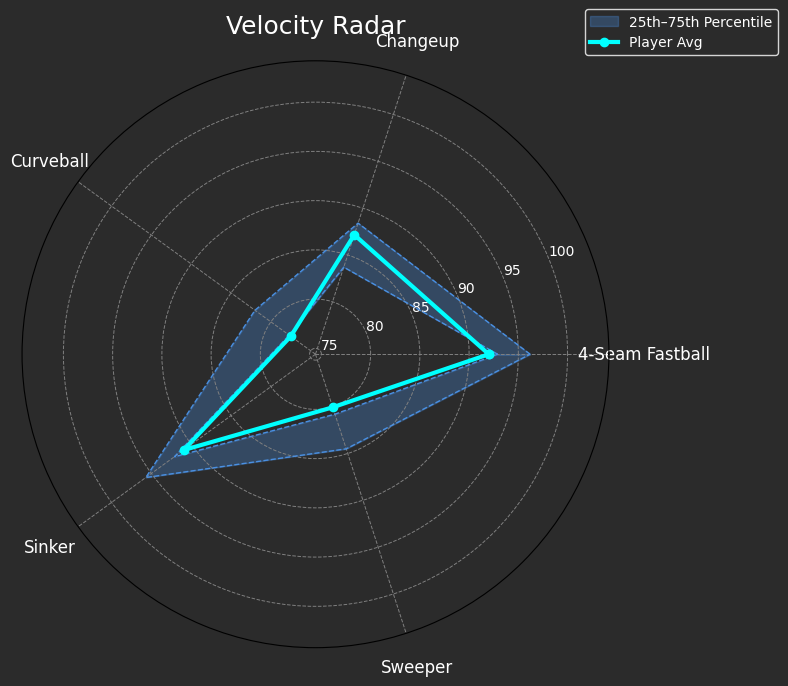

In [8]:
plot_player_radar(hb_data, data, stat="release_speed", title="Velocity Radar")

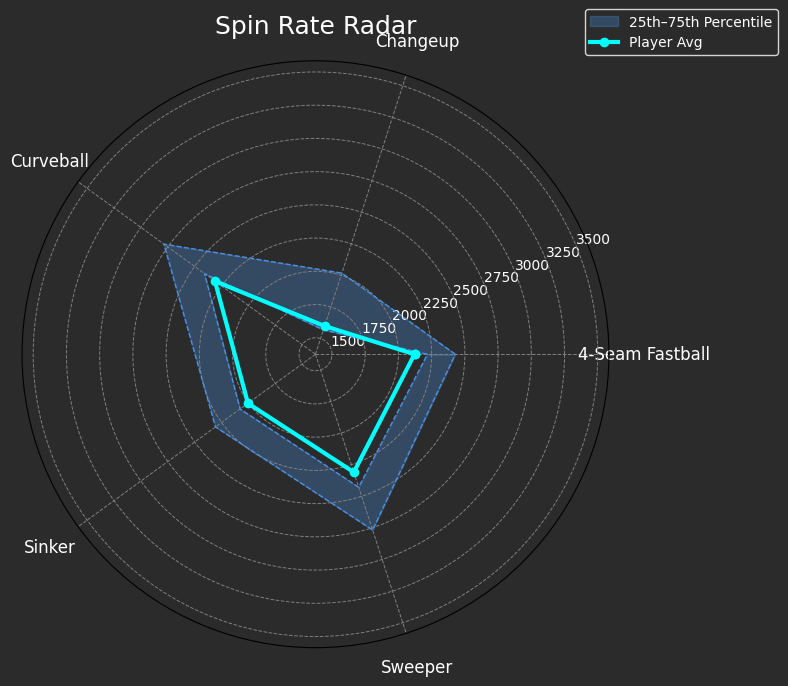

In [9]:
plot_player_radar(hb_data, data, stat="release_spin_rate", title="Spin Rate Radar")

In [132]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def plot_location_heatmap(player_stats, pitch, handedness = None, title=None):
    """
    Plots a heatmap of pitch location density for a given pitch type,
    with the strike zone overlaid.

    Parameters:
        player_stats (DataFrame): Data containing pitch-level statistics.
        pitch (str): Pitch type code (e.g., 'FF', 'SL').
        title (str, optional): Chart title. Defaults to "{player_name} - {pitch_name}".
    """
    
    # Select relevant columns and drop rows missing location
    df = player_stats[
        ["player_name", "pitch_type", "pitch_name", "plate_x", "plate_z", "sz_top", "sz_bot", 'stand']
    ].dropna(subset=["plate_x", "plate_z"])
    
    # Filter by pitch type
    df = df[df["pitch_type"] == pitch]
    if df.empty:
        print("No data available for this pitch type.")
        return
    
    if handedness:
        df = df[df['stand'] == handedness]
    
    # Extract labels
    pitch_name = df["pitch_name"].unique()[0]
    player_name = df["player_name"].unique()[0]
    
    # Custom dark gray background
    fig, ax = plt.subplots(figsize=(6,6), facecolor="#2b2b2b")
    ax.set_facecolor("#2b2b2b")
    
    # Custom colormap: fade from dark gray → light blue
    cmap = LinearSegmentedColormap.from_list("fade_blue", ["#2b2b2b", "#4A90E2"])
    
    # KDE heatmap with fewer, larger zones
    sns.kdeplot(
        data=df,
        x="plate_x",
        y="plate_z",
        fill=True,
        cmap=cmap,
        bw_adjust=1.5,       # smoother, broader contours
        levels=8,            # fewer levels → larger areas
        thresh=0.5,
        ax=ax
    )
    
    # Horizontal plate half-width in feet (17 inches plate)
    plate_half = 17 / 12 / 2.0  # 0.708 ft
    
    # Strike zone bounds: prefer per-pitch sz_top/sz_bot; else fallback
    if df["sz_top"].notna().any():
        zone_top = df["sz_top"].median()
        zone_bot = df["sz_bot"].median()
    else:
        zone_top, zone_bot = 3.5, 1.5
    zone_left, zone_right = -plate_half, plate_half
    
    # Draw strike zone rectangle (white for contrast)
    rect = plt.Rectangle(
        (zone_left, zone_bot),
        zone_right - zone_left,
        zone_top - zone_bot,
        fill=False, edgecolor="white", linewidth=1.2
    )
    ax.add_patch(rect)
    
    # Axis formatting
    ax.set_xlim(-2, 2)
    ax.set_ylim(0.5, 4.5)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Horizontal location (ft)", color="white")
    ax.set_ylabel("Vertical location (ft)", color="white")
    ax.set_title(title or f"{player_name} - {pitch_name}", color="white", pad=15)
    
    # Grid styling
    ax.grid(True, color="#444444", linestyle="--", linewidth=0.5)
    ax.tick_params(colors="white")
    
    # Clean up
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()


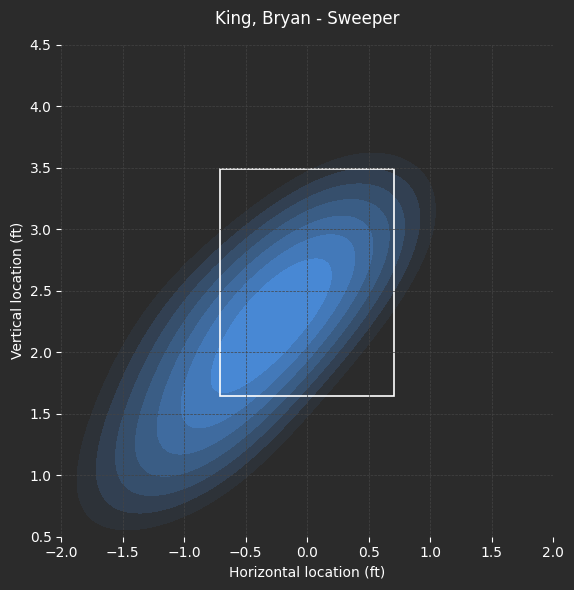

In [133]:
plot_location_heatmap(data2, pitch="ST", handedness = 'L')

/tmp/ipykernel_28910/267441125.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby("pitch_type", group_keys=False).apply(


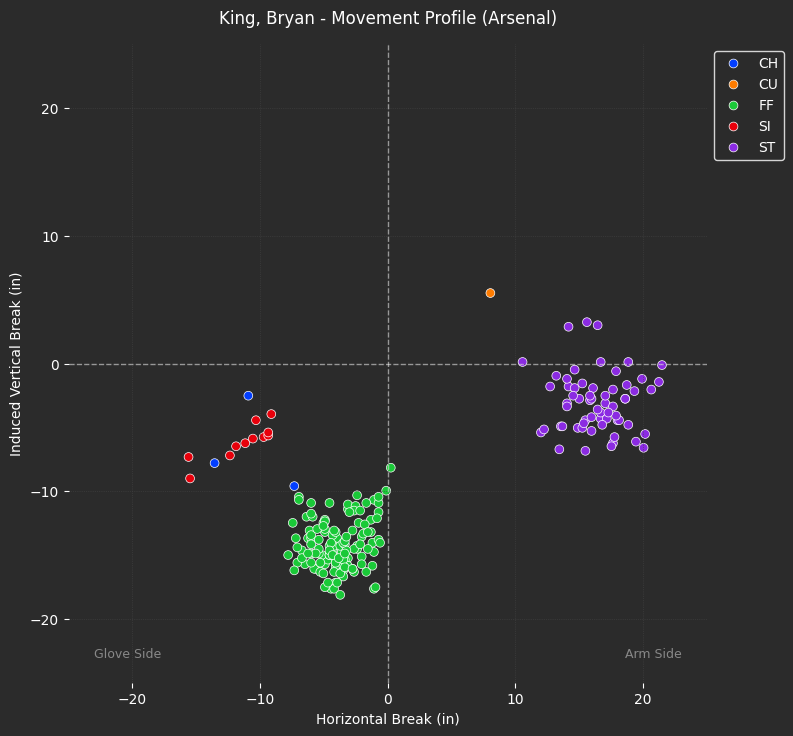

In [112]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_movement_scatter(player_stats, player_name, pitch_types=None, title=None):
    """
    Plots a scatter plot of pitch movement (Horizontal vs Vertical Break).
    It samples 20% of the data to keep the plot readable.
    
    Parameters:
        player_stats (DataFrame): Data containing pitch-level statistics.
        player_name (str): The name of the player to filter by.
        pitch_types (list or str, optional): Specific pitch types to plot (e.g. ['FF', 'SL']). 
                                             If None, plots ALL pitch types for that player.
        title (str, optional): Chart title.
    """
    
    # 1. Filter for Player and drop missing movement data
    # 'pfx_x' is horizontal break, 'pfx_z' is induced vertical break
    df = player_stats[player_stats["player_name"] == player_name].copy()
    df = df.dropna(subset=["pfx_x", "pfx_z", "pitch_type"])

    if player_name == 'King, Bryan':
        df['pfx_x'] = df['pfx_x'] * -1  # Adjust for left-handed pitcher
        df['pfx_z'] = df['pfx_z'] * -1  # Adjust for left-handed pitcher
    
    if df.empty:
        print(f"No data found for player: {player_name}")
        return

    # 2. Filter specific pitches (if requested), otherwise keep all
    if pitch_types:
        if isinstance(pitch_types, str):
            pitch_types = [pitch_types] # Handle single string input
        df = df[df["pitch_type"].isin(pitch_types)]
        
    # 3. Data Sampling: 20% of each pitch type
    # We group by pitch type first so we don't accidentally delete all rare pitches
    try:
        df_sampled = df.groupby("pitch_type", group_keys=False).apply(
            lambda x: x.sample(frac=0.2, random_state=42)
        )
    except ValueError:
        # Fallback if dataset is too small to sample
        df_sampled = df

    # 4. Unit Conversion: Feet to Inches
    df_sampled["hb_in"] = df_sampled["pfx_x"]
    df_sampled["ivb_in"] = df_sampled["pfx_z"]

    
    # --- Plotting Setup ---
    
    # Custom dark gray background
    fig, ax = plt.subplots(figsize=(8, 8), facecolor="#2b2b2b")
    ax.set_facecolor("#2b2b2b")
    
    # Color Palette: Bright colors to pop against dark background
    # We define a custom palette or use a bright seaborn one
    unique_pitches = df_sampled["pitch_type"].unique()
    palette = sns.color_palette("bright", n_colors=len(unique_pitches))
    
    # Scatter Plot
    sns.scatterplot(
        data=df_sampled,
        x="hb_in",
        y="ivb_in",
        hue="pitch_type",     # Color by pitch type
        palette=palette,
        s=40,                 # Dot size
        alpha=1,            # Transparency (helps visualize overlapping density)
        edgecolor="white",    # Slight white edge to make dots pop
        linewidth=0.5,
        ax=ax
    )
    
    # Draw (0,0) Crosshairs (Gravity-only reference)
    ax.axhline(0, color="white", linestyle="--", linewidth=1, alpha=0.5)
    ax.axvline(0, color="white", linestyle="--", linewidth=1, alpha=0.5)
    
    # Axis formatting (Standard movement plot range)
    ax.set_xlim(-25, 25)
    ax.set_ylim(-25, 25)
    ax.set_aspect("equal", adjustable="box")
    
    # Labels
    ax.set_xlabel("Horizontal Break (in)", color="white", fontsize=10)
    ax.set_ylabel("Induced Vertical Break (in)", color="white", fontsize=10)
    ax.set_title(title or f"{player_name} - Movement Profile (Arsenal)", color="white", pad=15, fontsize=12)
    
    # Grid styling
    ax.grid(True, color="#444444", linestyle=":", linewidth=0.5)
    ax.tick_params(colors="white")
    
    # Custom Legend formatting
    legend = ax.legend(frameon=True, facecolor="#2b2b2b", edgecolor="white", loc='upper left', bbox_to_anchor=(1, 1))
    for text in legend.get_texts():
        text.set_color("white")
    
    # Annotation for Glove/Arm side
    ax.text(23, -23, "Arm Side", color="#888888", fontsize=9, ha="right")
    ax.text(-23, -23, "Glove Side", color="#888888", fontsize=9, ha="left")

    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

plot_movement_scatter(hb_data, player_name="King, Bryan", pitch_types=None, title=None)

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

def plot_usage(player_data: pd.DataFrame,
               save_png: bool = False,
               pitch_to_save: str = None,
               color="#4A90E2",
               figsize=(6,5),
               annotate=True) -> dict:
    """
    Calculate and visualize pitch usage by count for a given player dataset.
    Assumes batter handedness has already been filtered in player_data.

    Parameters:
        player_data (DataFrame): Pitch-level data for one player (already filtered by handedness).
        save_png (bool): Whether to save a PNG of a specific pitch table.
        pitch_to_save (str): Pitch type to save if save_png=True.
        color (str): Base color for gradient (default blue).
        figsize (tuple): Size of each figure.
        annotate (bool): Whether to annotate cells with values.

    Returns:
        dict: Dictionary of matplotlib Figure objects keyed by pitch type.
    """
    df = player_data.copy()

    # Create Count column (balls-strikes)
    df['Count'] = df['balls'].astype(str) + '-' + df['strikes'].astype(str)

    # Calculate pitch usage by count
    usage = df.groupby(['Count', 'pitch_type'])['pitch_type'].count().reset_index(name='Usage')

    # Pivot to wide format (counts × pitch types)
    usage = usage.pivot(index='Count', columns='pitch_type', values='Usage').fillna(0).reset_index()

    # Convert counts to percentages row-wise
    for idx, row in usage.iterrows():
        total = row[1:].sum()
        for col in usage.columns[1:]:
            usage.loc[idx, col] = (row[col] / total) * 100 if total > 0 else 0

    # Split Count into Balls and Strikes
    usage[['Balls', 'Strikes']] = usage['Count'].astype(str).str.split('-', expand=True).astype(int)

    # All pitch types
    pitch_types = usage.columns[1:-2]

    figs = {}

    # Custom colormap: light → dark
    cmap = LinearSegmentedColormap.from_list("single_hue", ["#ffffff", color])

    for pitch in pitch_types:
        # Pivot table: Rows = Balls, Columns = Strikes
        pivot = usage.pivot(index='Balls', columns='Strikes', values=pitch).sort_index()

        # Create figure
        fig, ax = plt.subplots(figsize=figsize, facecolor="#2b2b2b")
        ax.set_facecolor("#2b2b2b")

        sns.heatmap(
            pivot,
            ax=ax,
            cmap=cmap,
            annot=annotate,
            fmt=".1f" if annotate else "",
            cbar=True,
            linewidths=0.5,
            linecolor="#3a3a3a"
        )

        # Labels and title
        ax.set_xlabel("Strikes", color="white", labelpad=10)
        ax.set_ylabel("Balls", color="white", labelpad=10)
        ax.set_title(f"{pitch} Usage by Count", color="white", pad=14)

        # Tick styling
        ax.tick_params(colors="white")
        ax.set_xticklabels(ax.get_xticklabels(), color="white", rotation=0)
        ax.set_yticklabels(ax.get_yticklabels(), color="white", rotation=0)

        # Colorbar styling
        cbar = ax.collections[0].colorbar
        cbar.ax.set_facecolor("#2b2b2b")
        cbar.outline.set_edgecolor("#cccccc")
        cbar.ax.yaxis.set_tick_params(color="white")
        for lbl in cbar.ax.get_yticklabels():
            lbl.set_color("white")
        cbar.set_label("Usage (%)", color="white")

        plt.tight_layout()

        if save_png and pitch_to_save == pitch:
            fig.savefig(f"{pitch}_usage.png", dpi=200, facecolor=fig.get_facecolor())

        figs[pitch] = fig

    return figs


/tmp/ipykernel_28910/2212168891.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figs["FF"].show()


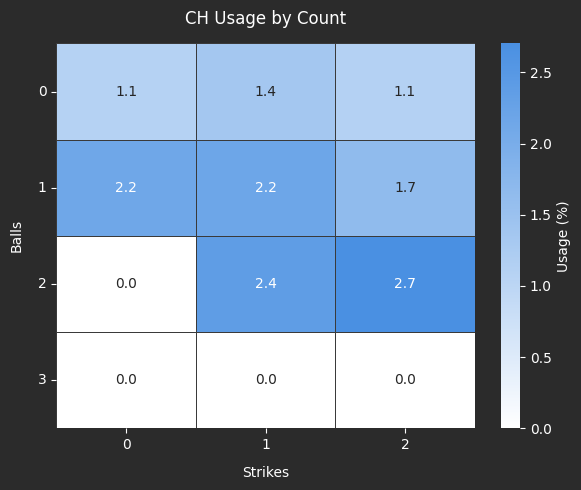

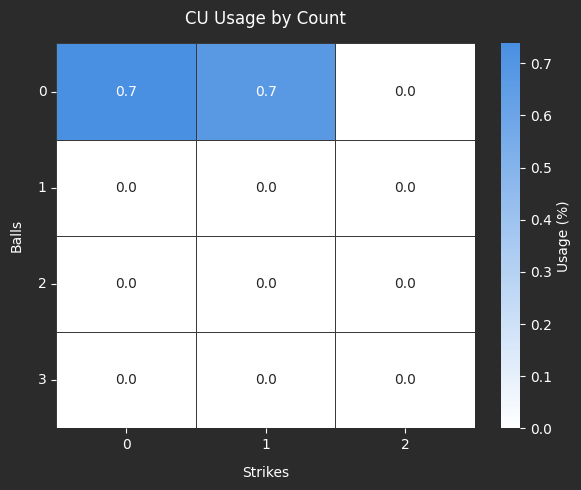

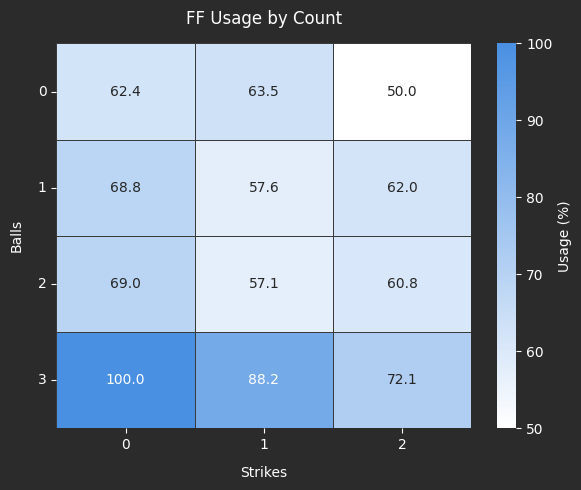

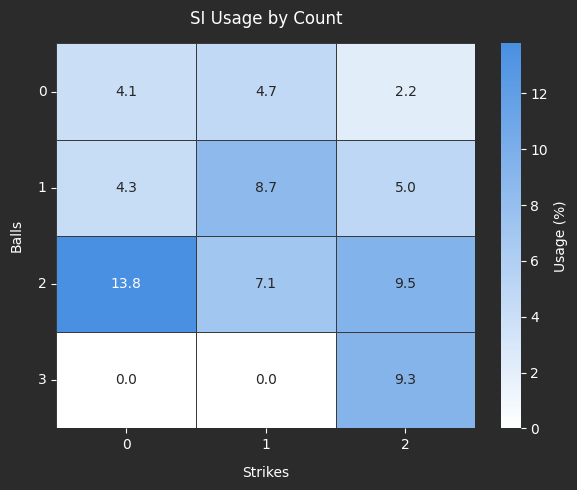

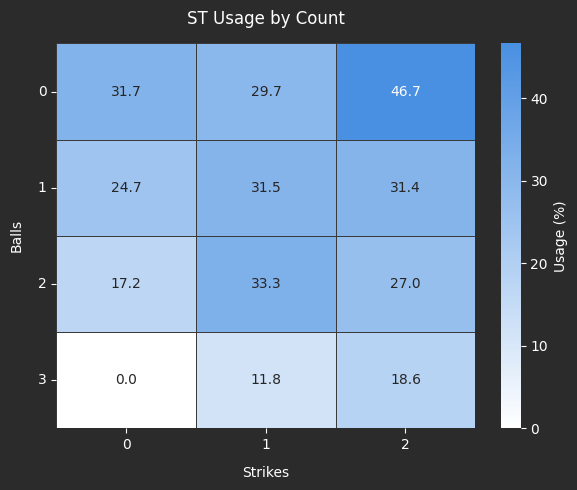

In [14]:
figs = plot_usage(hb_data, save_png=True, pitch_to_save="FF")
figs["FF"].show()